In [1]:
import numpy as np
from iblatlas.atlas import AllenAtlas
from iblatlas.regions import BrainRegions
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
from matplotlib import pyplot as plt
import pickle as pkl
from glob import glob

In [44]:
ba = AllenAtlas()
br = BrainRegions()

widefield_regions = ["ACAd", "AUDd", "AUDp", "AUDpo", "AUDv", "FRP", "MOB", "MOp", "MOs", "PL", "RSPagl", "RSPd", "RSPv", "SSp-bfd", "SSp-ll", "SSp-m", "SSp-n", "SSp-tr", "SSp-ul", "SSp-un", "SSs", "TEa", "VISa", "VISal", "VISam", "VISl", "VISli", "VISp", "VISpl", "VISpm", "VISpor", "VISrl"]

region_ids = br.acronym2id(widefield_regions)

parent_mapping = {}

for rid in region_ids:

    ancestors = br.ancestors(rid)
    

    num_ancestors = len(ancestors.id)
    region_acronym = br.id2acronym(rid)[0]
    

    if num_ancestors > 5:
        major_parent_acronym = ancestors.acronym[6] 
        parent_mapping[region_acronym] = major_parent_acronym
    else:
        parent_mapping[region_acronym] = region_acronym

In [46]:
unique_parents = list(set(parent_mapping.values()))

In [48]:
parent_ids = br.acronym2id(unique_parents)

parent_centroids = []


for i, pid in enumerate(parent_ids):

    descendant_ids = br.descendants(pid)['id']
    

    mask = np.isin(ba.label, descendant_ids)
    z, y, x = np.where(mask)
    
    if len(x) == 0:
        print(f"Warning: No voxels found for {unique_parents[i]}")
        parent_centroids.append([np.nan, np.nan, np.nan])
    else:
        parent_centroids.append([np.mean(x), np.mean(y), np.mean(z)])

In [49]:
parent_centroids = np.array(parent_centroids)
parent_distance_matrix = squareform(pdist(parent_centroids, metric='euclidean'))

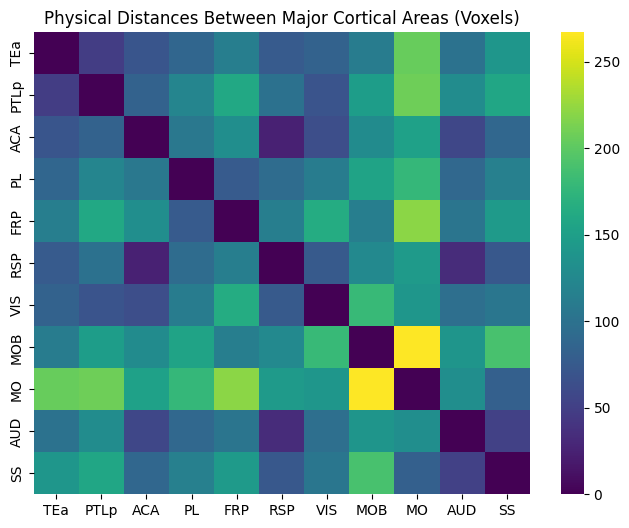

In [54]:
plt.figure(figsize=(8, 6))
sns.heatmap(parent_distance_matrix, xticklabels=unique_parents, yticklabels=unique_parents, cmap="viridis")
plt.title("Physical Distances Between Major Cortical Areas (Voxels)")
plt.show()

In [80]:
from iblatlas.plots import plot_swanson_vector, plot_scalar_on_slice
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

Text(0.5, 1.0, 'Parent clusters')

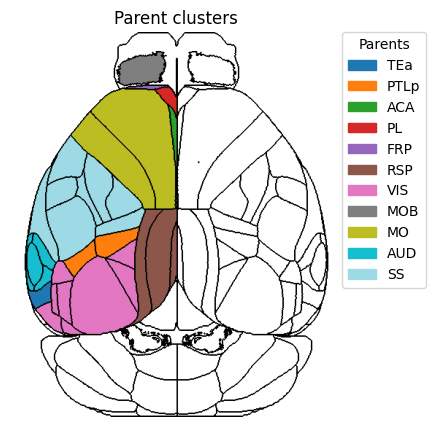

In [125]:
unique_parents = list(set(parent_mapping.values()))


parent_to_int = {parent: i for i, parent in enumerate(unique_parents)}


acronyms_beryl = np.array(widefield_regions)
values_beryl = np.array([parent_to_int[parent_mapping[reg]] for reg in widefield_regions])


fig, ax = plt.subplots(figsize=(5, 5))

plot_scalar_on_slice(
    acronyms_beryl, 
    values_beryl, 
    slice='top', 
    mapping='Beryl',  
    hemisphere='left', 
    background='boundary', 
    cmap='tab20',        # Categorical colormap
    brain_atlas=ba, 
    show_cbar=False,     # Disabled so we can build a legend instead
    ax=ax,
    annotate=True
)

cmap = plt.get_cmap('tab20')
norm = plt.Normalize(vmin=values_beryl.min(), vmax=values_beryl.max())

legend_patches = []
for parent, val in parent_to_int.items():
    color = cmap(norm(val))
    legend_patches.append(mpatches.Patch(color=color, label=parent))

ax.legend(handles=legend_patches, title="Parents", 
          bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=0.)

ax.axis('off')
ax.set_title("Parent clusters")

In [ ]:
cmap = plt.get_cmap('Spectral', 32)
fig, ax = plt.subplots(figsize=(5, 5))
plot_scalar_on_slice(
    acronyms_beryl, 
    np.arange(len(acronyms_beryl)), 
    slice='top', 
    mapping='Beryl',  
    hemisphere='left', 
    background='boundary', 
    brain_atlas=ba, 
    show_cbar=False,
    annotate=True,
    cmap=cmap,
    ax=ax
)
ax.axis('off')
ax.set_title("Recorded regions")

norm = mcolors.BoundaryNorm(np.arange(-0.5, 32 + 0.5, 1), cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Shrink the colorbar slightly and pad it so it doesn't run off the screen
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, ticks=np.arange(32))

# Apply the acronyms. Using a small font size is mandatory here.
cbar.ax.set_yticklabels(widefield_regions, fontsize=8)

In [29]:

from manifold.utils import get_trial_masks


def return_labels(trials, condition):
    masks, _ = get_trial_masks(trials)
    n_trials = len(masks['cong_correct'])
    labels = np.zeros(n_trials)

    if condition == 'congruence':
        conda = masks['cong_correct'] | masks['cong_incorrect']
        condb = masks['incong_correct'] | masks['incong_incorrect']       

    elif condition == 'correctness':
        conda = masks['incong_correct']
        condb = masks['incong_incorrect']

    labels[conda] = 1
    labels[condb] = -1 

    valid_mask = conda|condb # type: ignore
    return labels[valid_mask], valid_mask
